Load Data

In [6]:
import pandas as pd

df = pd.read_csv("../data/shots_sample.csv")
df.head()

,club_name,ball_speed_mph,launch_angle_deg,azimuth_deg,spin_rpm,spin_axis_deg
0,Driver,155,13,0,2500,0
1,Driver,152,12,2,2700,4
2,Driver,149,11,-3,2900,-6
3,7 Iron,120,18,0,6200,0
4,7 Iron,118,17,1,6400,3


Unit Conversion

In [7]:
import numpy as np

MPH_TO_MPS = 0.44704

df["ball_speed_mps"] = df["ball_speed_mph"] * MPH_TO_MPS
df["launch_angle_rad"] = np.radians(df["launch_angle_deg"])
df["azimuth_rad"] = np.radians(df["azimuth_deg"])

Simple Physics Formulas

In [8]:
g = 9.81

df["vx"] = df["ball_speed_mps"] * np.cos(df["launch_angle_rad"]) * np.cos(df["azimuth_rad"])
df["vy"] = df["ball_speed_mps"] * np.cos(df["launch_angle_rad"]) * np.sin(df["azimuth_rad"])
df["vz"] = df["ball_speed_mps"] * np.sin(df["launch_angle_rad"])

Compute Outcomes

In [9]:
df["flight_time"] = (2 * df["vz"]) / g
df["carry_x"] = df["vx"] * df["flight_time"]
df["carry_y"] = df["vy"] * df["flight_time"]
df["apex"] = (df["vz"] ** 2) / (2 * g)

df[["club_name", "carry_x", "carry_y", "apex"]]

,club_name,carry_x,carry_y,apex
0,Driver,214.550297,0.000000,12.383210
1,Driver,191.319658,6.681030,10.172759
2,Driver,169.190558,-8.866901,8.233111
3,7 Iron,172.426868,0.000000,14.006221
4,7 Iron,158.592731,2.768246,12.123512
5,7 Iron,186.560957,-6.514852,16.069311
6,PW,152.421133,0.000000,20.260939
7,PW,142.521752,2.487726,18.157380
8,PW,162.525520,-2.836893,22.525772


Plot of Dispersion

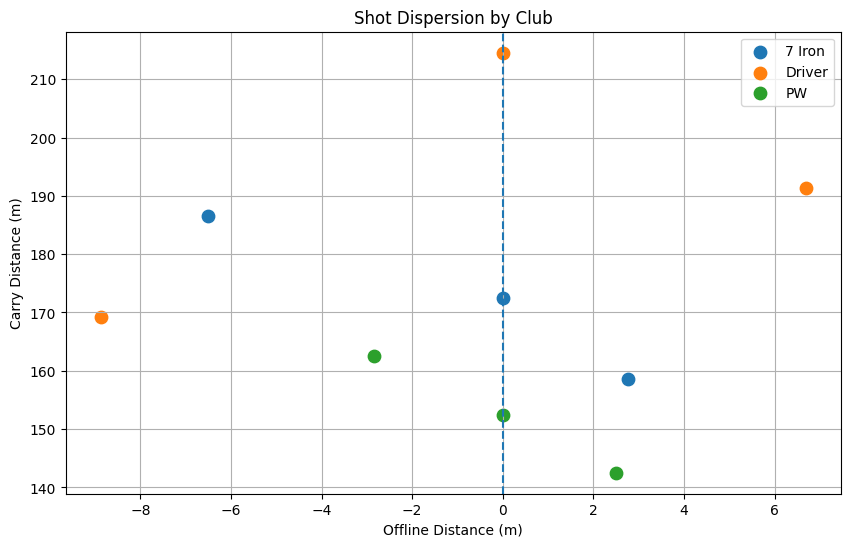

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for club, group in df.groupby("club_name"):
    plt.scatter(group["carry_y"], group["carry_x"], label=club, s=80)

plt.axvline(0, linestyle="--")
plt.xlabel("Offline Distance (m)")
plt.ylabel("Carry Distance (m)")
plt.title("Shot Dispersion by Club")
plt.legend()
plt.grid(True)
plt.show()